# Example: Generalized Linear Models (GLM) via IRLS

Demonstrates count modeling via `PoissonRegressionScratch` and binary classification via `LogisticRegressionScratch` with dual visual diagnostic curves.

Poisson Pseudo-R2: 0.8281
Recovered Weights: [ 0.838 -0.522] (truth: [0.8, -0.5])
Logistic Accuracy: 74.00%


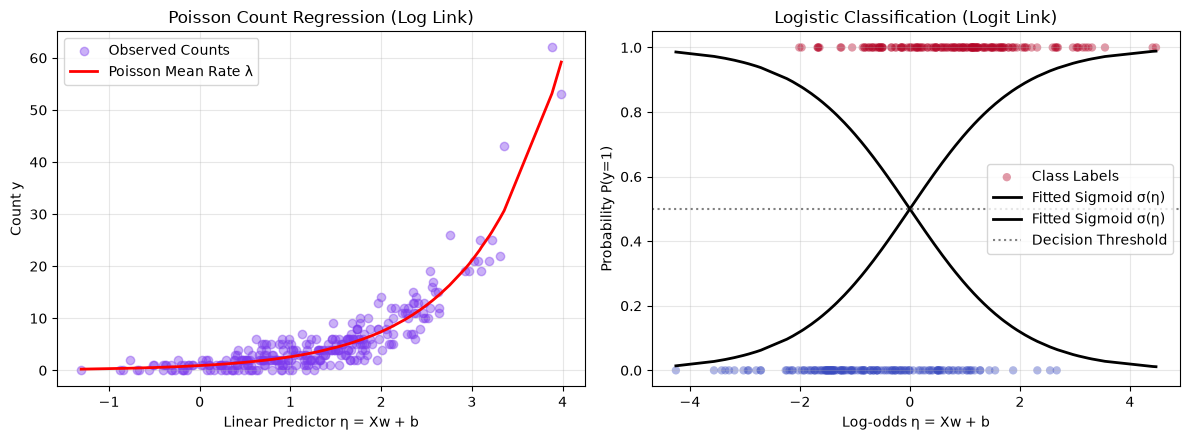

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.glm import PoissonRegressionScratch, LogisticRegressionScratch

np.random.seed(42)
N = 300
X = np.random.randn(N, 2)

# 1. Poisson Counts: y ~ Poisson(exp(Xw + b))
eta = 0.8 * X[:, 0] - 0.5 * X[:, 1] + 1.2
mu = np.exp(eta)
y_counts = np.random.poisson(mu)

poisson = PoissonRegressionScratch(max_iter=25).fit(X, y_counts)
print(f"Poisson Pseudo-R2: {poisson.pseudo_r2_:.4f}")
print(f"Recovered Weights: {np.round(poisson.weights, 3)} (truth: [0.8, -0.5])")

# 2. Logistic Binary: y ~ Bernoulli(sigmoid(Xw + b))
p = 1.0 / (1.0 + np.exp(-(1.2 * X[:, 0] - 1.5 * X[:, 1])))
y_bin = (np.random.rand(N) < p).astype(int)

logistic = LogisticRegressionScratch(max_iter=25).fit(X, y_bin)
print(f"Logistic Accuracy: {logistic.score(X, y_bin)*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Poisson counts vs linear predictor
sorted_idx = np.argsort(eta)
axes[0].scatter(eta, y_counts, alpha=0.4, color='#7c3aed', label='Observed Counts')
axes[0].plot(eta[sorted_idx], poisson.predict(X)[sorted_idx], 'r-', lw=2, label='Poisson Mean Rate λ')
axes[0].set_title("Poisson Count Regression (Log Link)")
axes[0].set_xlabel("Linear Predictor η = Xw + b")
axes[0].set_ylabel("Count y")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Logistic classification sigmoid curve
p_pred = logistic.predict_proba(X)
log_eta = X @ logistic.weights + logistic.bias
s_idx = np.argsort(log_eta)
axes[1].scatter(log_eta, y_bin, alpha=0.4, c=y_bin, cmap='coolwarm', edgecolors='none', label='Class Labels')
axes[1].plot(log_eta[s_idx], p_pred[s_idx], 'k-', lw=2, label='Fitted Sigmoid σ(η)')
axes[1].axhline(0.5, color='gray', linestyle=':', label='Decision Threshold')
axes[1].set_title("Logistic Classification (Logit Link)")
axes[1].set_xlabel("Log-odds η = Xw + b")
axes[1].set_ylabel("Probability P(y=1)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### What You Learned
- Extending linear models to discrete event counts and classification using IRLS.
- Viewing fitted non-linear link functions and probability curves.